# Práctica Final - Machine Learning y Ciberseguridad

Vamos a intentar predecir qué acción se toma cuando hay un ciberataque (Action Taken) 
a partir de un dataset con 40.000 incidencias. Es un problema de clasificación supervisada 
porque tenemos las respuestas correctas en los datos.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de datos y exploración

Lo primero es cargar el dataset y ver qué pinta tiene: cuántas filas y columnas hay, 
qué tipo de datos tiene cada columna y si hay valores vacíos.

In [2]:
df = pd.read_csv('data/cybersecurity_attacks.csv')
print(df.shape)
df.head().T

(40000, 25)


,0,1,2,3,4
Timestamp,2023-05-30 06:33:58,2020-08-26 07:08:30,2022-11-13 08:23:25,2023-07-02 10:38:46,2023-07-16 13:11:07
Source IP Address,103.216.15.12,78.199.217.198,63.79.210.48,163.42.196.10,71.166.185.76
Destination IP Address,84.9.164.252,66.191.137.154,198.219.82.17,101.228.192.255,189.243.174.238
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Payload Data,Qui natus odio asperiores nam. Optio nobis ius...,Aperiam quos modi officiis veritatis rem. Omni...,Perferendis sapiente vitae soluta. Hic delectu...,Totam maxime beatae expedita explicabo porro l...,Odit nesciunt dolorem nisi iste iusto. Animi v...


In [3]:
df.dtypes

Timestamp                  object
Source IP Address          object
Destination IP Address     object
Source Port                 int64
Destination Port            int64
Protocol                   object
Packet Length               int64
Packet Type                object
Traffic Type               object
Payload Data               object
Malware Indicators         object
Anomaly Scores            float64
Alerts/Warnings            object
Attack Type                object
Attack Signature           object
Action Taken               object
Severity Level             object
User Information           object
Device Information         object
Network Segment            object
Geo-location Data          object
Proxy Information          object
Firewall Logs              object
IDS/IPS Alerts             object
Log Source                 object
dtype: object

In [4]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [5]:
df.describe(include='all')

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
count,40000,40000,40000,40000.000000,40000.000000,40000,40000.000000,40000,40000,40000,...,40000,40000,40000,40000,40000,40000,20149,20039,19950,40000
unique,39997,40000,40000,NaN,NaN,3,NaN,2,3,40000,...,3,3,32389,32104,3,8723,20148,1,1,2
top,2022-06-11 14:28:15,103.216.15.12,84.9.164.252,NaN,NaN,ICMP,NaN,Control,DNS,Qui natus odio asperiores nam. Optio nobis ius...,...,Blocked,Medium,Ishaan Chaudhari,Mozilla/5.0 (compatible; MSIE 6.0; Windows NT ...,Segment C,"Ghaziabad, Meghalaya",39.123.165.122,Log Data,Alert Data,Firewall
freq,2,1,1,NaN,NaN,13429,NaN,20237,13376,1,...,13529,13435,6,35,13408,16,2,20039,19950,20116
mean,NaN,NaN,NaN,32970.356450,33150.868650,NaN,781.452725,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,18560.425604,18574.668842,NaN,416.044192,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1027.000000,1024.000000,NaN,64.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,16850.750000,17094.750000,NaN,420.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,32856.000000,33004.500000,NaN,782.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,48928.250000,49287.000000,NaN,1143.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().any()

Timestamp                 False
Source IP Address         False
Destination IP Address    False
Source Port               False
Destination Port          False
Protocol                  False
Packet Length             False
Packet Type               False
Traffic Type              False
Payload Data              False
Malware Indicators         True
Anomaly Scores            False
Alerts/Warnings            True
Attack Type               False
Attack Signature          False
Action Taken              False
Severity Level            False
User Information          False
Device Information        False
Network Segment           False
Geo-location Data         False
Proxy Information          True
Firewall Logs              True
IDS/IPS Alerts             True
Log Source                False
dtype: bool

Hay 5 columnas con valores nulos: Malware Indicators, Alerts/Warnings, Proxy Information, 
Firewall Logs e IDS/IPS Alerts. Las columnas numéricas son solo 4 (Source Port, 
Destination Port, Packet Length, Anomaly Scores), el resto es texto.

In [7]:
df['Action Taken'].value_counts()

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

Las tres clases están muy equilibradas, unas 13.300 muestras cada una. Eso significa 
que podemos usar accuracy como métrica sin problema.

## 2. Preprocesamiento

Ahora toca preparar los datos para que un modelo pueda trabajar con ellos. Los modelos 
solo entienden números, así que hay que convertir las columnas de texto a números y 
eliminar las que no sirven para nada.

Primero elimino las columnas que tienen demasiados valores únicos (como las IPs, 
los timestamps o el texto del payload) porque un modelo no puede aprender nada de ellas. 
También elimino Proxy Information, Firewall Logs e IDS/IPS Alerts porque tienen casi 
la mitad de los valores vacíos.

Las columnas Malware Indicators y Alerts/Warnings también tienen muchos nulos, pero las 
convierto en 0 y 1 (tiene valor o no tiene) porque esa información sí puede ser útil.

In [8]:
columns_to_drop = ['Timestamp', 'Source IP Address', 'Destination IP Address',
                   'Payload Data', 'User Information', 'Device Information',
                   'Geo-location Data', 'Proxy Information', 'Firewall Logs',
                   'IDS/IPS Alerts']

df = df.drop(columns_to_drop, axis=1)

df['Malware Indicators'] = df['Malware Indicators'].apply(lambda x: 0 if pd.isnull(x) else 1)
df['Alerts/Warnings'] = df['Alerts/Warnings'].apply(lambda x: 0 if pd.isnull(x) else 1)

df.head().T

,0,1,2,3,4
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Malware Indicators,1,1,1,0,0
Anomaly Scores,28.67,51.5,87.42,15.79,0.52
Alerts/Warnings,0,0,1,1,1
Attack Type,Malware,Malware,DDoS,Malware,DDoS


Ahora codifico las columnas de texto a números con LabelEncoder, que es lo que 
usamos en clase. Creo un encoder para cada columna para saber después qué número 
corresponde a qué valor.

In [9]:
from sklearn.preprocessing import LabelEncoder

le_protocol = LabelEncoder()
le_packet = LabelEncoder()
le_traffic = LabelEncoder()
le_attack = LabelEncoder()
le_severity = LabelEncoder()
le_network = LabelEncoder()
le_action = LabelEncoder()
le_signature = LabelEncoder()
le_log = LabelEncoder()

df['Protocol'] = le_protocol.fit_transform(df['Protocol'])
df['Packet Type'] = le_packet.fit_transform(df['Packet Type'])
df['Traffic Type'] = le_traffic.fit_transform(df['Traffic Type'])
df['Attack Type'] = le_attack.fit_transform(df['Attack Type'])
df['Severity Level'] = le_severity.fit_transform(df['Severity Level'])
df['Network Segment'] = le_network.fit_transform(df['Network Segment'])
df['Action Taken'] = le_action.fit_transform(df['Action Taken'])
df['Attack Signature'] = le_signature.fit_transform(df['Attack Signature'])
df['Log Source'] = le_log.fit_transform(df['Log Source'])

print(list(le_action.classes_))
df.head().T

['Blocked', 'Ignored', 'Logged']


,0,1,2,3,4
Source Port,31225.00,17245.0,16811.00,20018.00,6131.00
Destination Port,17616.00,48166.0,53600.00,32534.00,26646.00
Protocol,0.00,0.0,2.00,2.00,1.00
Packet Length,503.00,1174.0,306.00,385.00,1462.00
Packet Type,1.00,1.0,0.00,1.00,1.00
Traffic Type,2.00,2.0,2.00,2.00,0.00
Malware Indicators,1.00,1.0,1.00,0.00,0.00
Anomaly Scores,28.67,51.5,87.42,15.79,0.52
Alerts/Warnings,0.00,0.0,1.00,1.00,1.00
Attack Type,2.00,2.0,0.00,2.00,0.00


## 3. Histogramas por clase

Pinto los histogramas de cada columna separados por las tres clases de Action Taken 
para ver si alguna columna sirve para distinguir entre Blocked, Ignored y Logged. 
Si las tres clases se solapan en una columna significa que esa columna no aporta 
información útil para predecir.

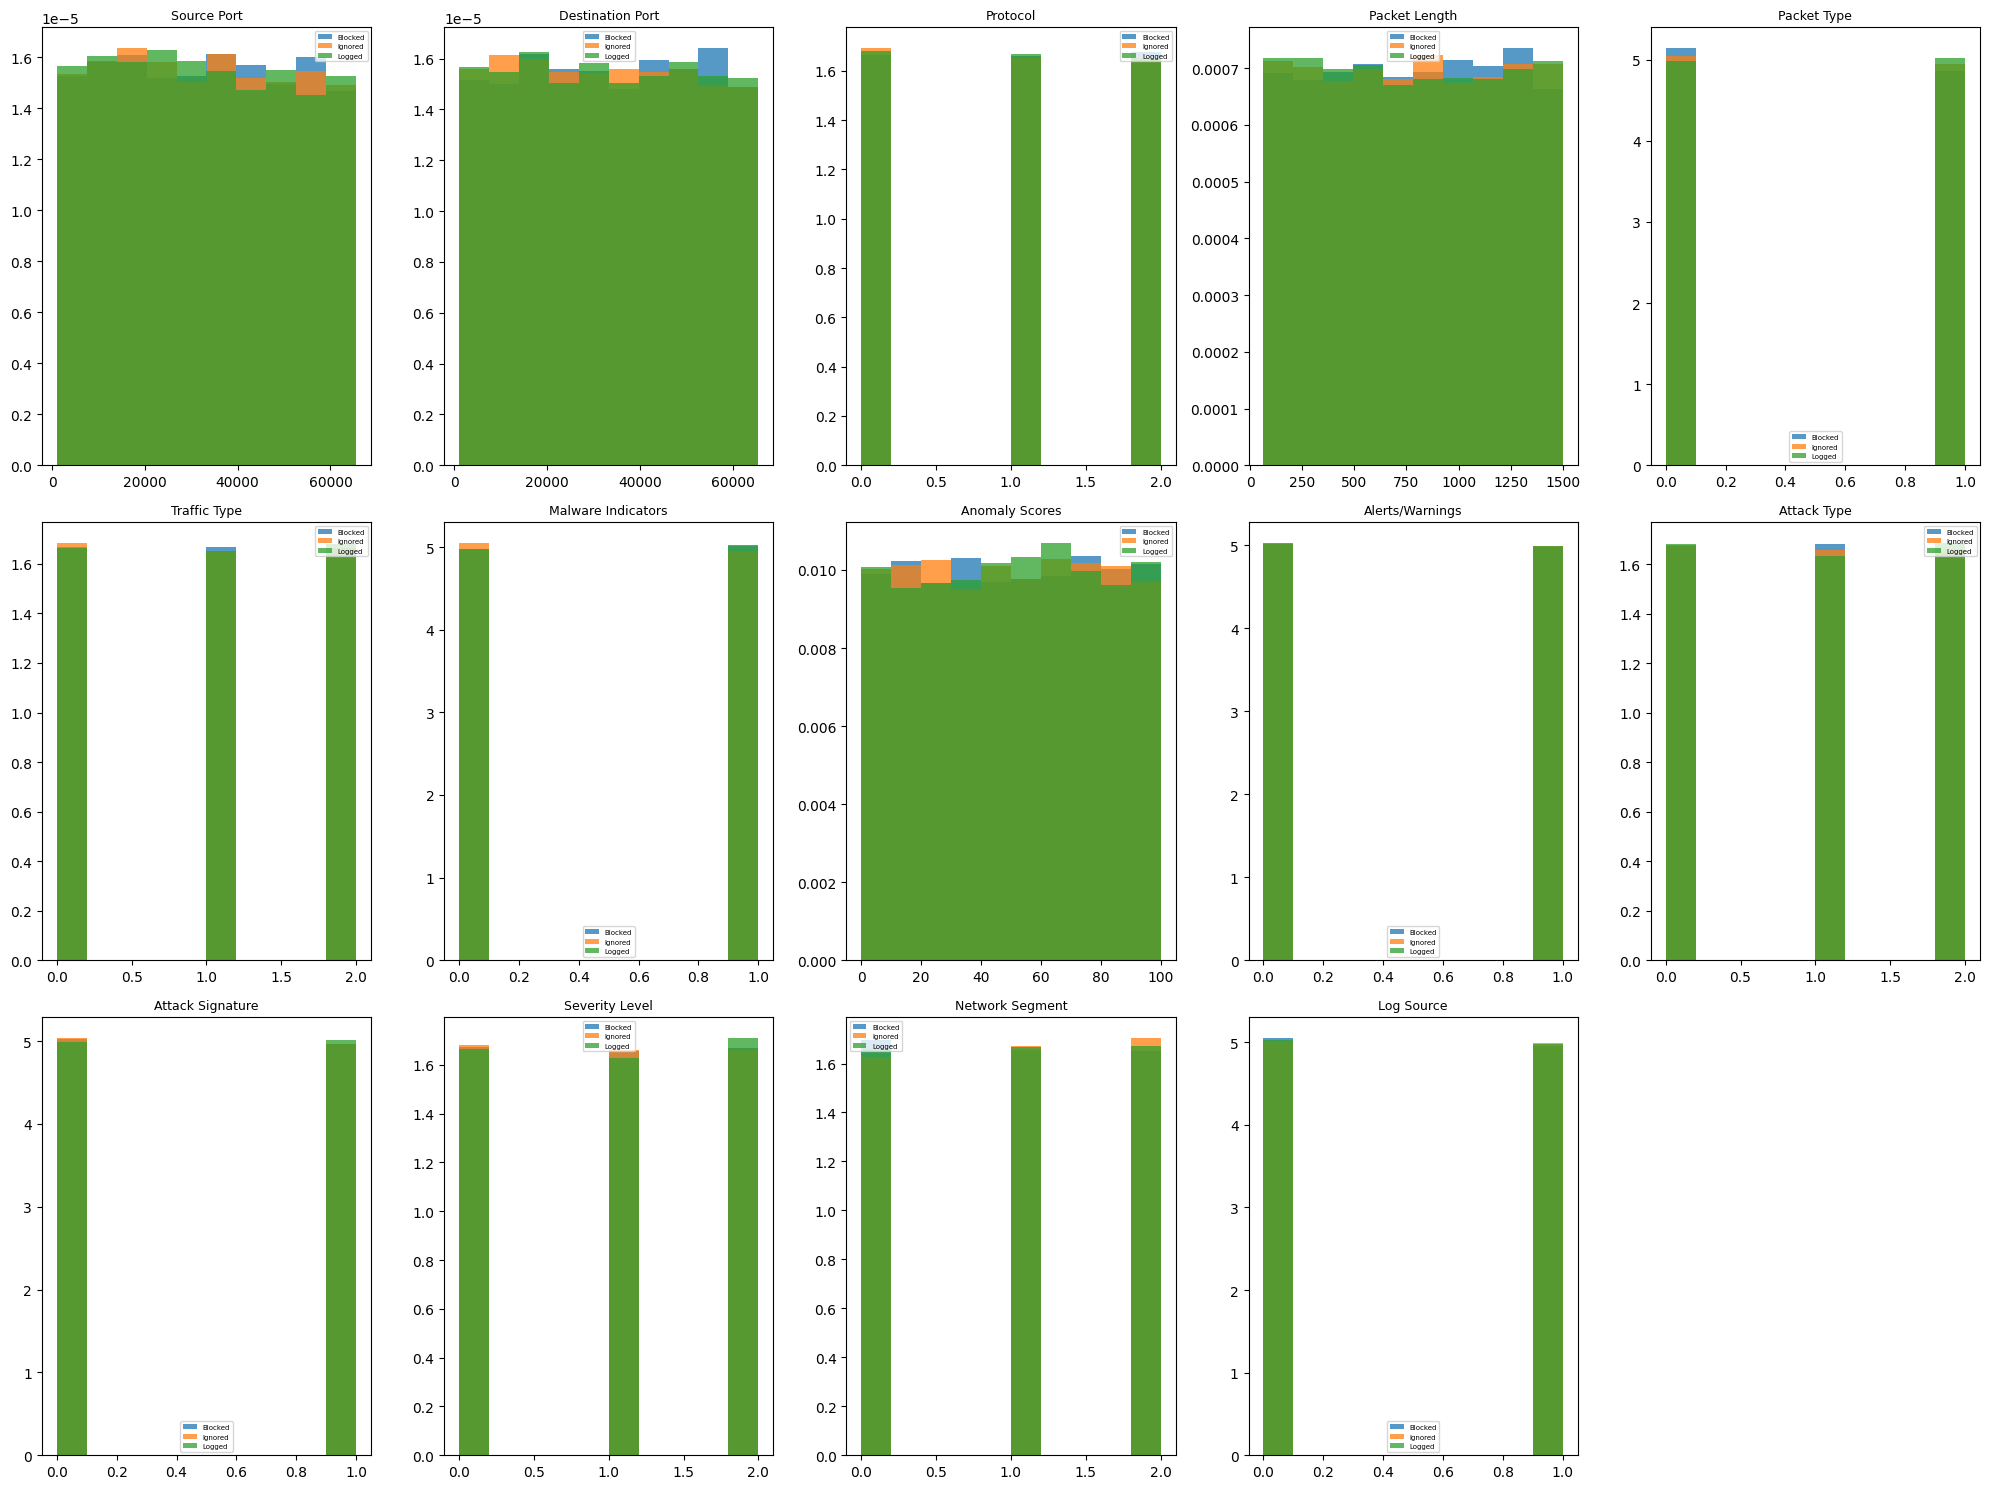

In [10]:
features = df.columns.drop(['Action Taken'])

plt.figure(figsize=(20,15))

idx_0 = df['Action Taken'] == 0
idx_1 = df['Action Taken'] == 1
idx_2 = df['Action Taken'] == 2

for i, feature in enumerate(features):
    plt.subplot(3, 5, i+1)
    plt.hist(df.loc[idx_0, feature], density=1, alpha=0.75, label='Blocked')
    plt.hist(df.loc[idx_1, feature], density=1, alpha=0.75, label='Ignored')
    plt.hist(df.loc[idx_2, feature], density=1, alpha=0.75, label='Logged')
    plt.legend(fontsize=5)
    plt.title(feature, fontsize=9)

plt.tight_layout()
plt.show()

Los histogramas muestran que en todas las columnas las tres clases se solapan 
completamente. No hay ninguna variable donde una clase se separe de las otras. 
Las columnas categóricas como Protocol, Traffic Type, Network Segment, Attack Type 
y Severity Level están distribuidas prácticamente al 33% exacto entre las tres clases. 
Esto ya me hace sospechar que va a ser difícil que un modelo aprenda algo útil, 
pero vamos a intentarlo igualmente.

## 4. Preparación de datos para el modelo

Separo las columnas que voy a usar para predecir (X) de la columna que quiero 
predecir (y). Luego divido los datos en train (80%) y test (20%) con stratify 
para que las tres clases mantengan la misma proporción. Después escalo los datos 
con StandardScaler para que todas las columnas tengan la misma escala.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = df.columns.drop(['Action Taken'])
X = df[features].values
y = df['Action Taken'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print('Datos train: ', X_train.shape)
print('Datos test:  ', X_test.shape)

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test = scaler.transform(X_test)

Datos train:  (32000, 14)
Datos test:   (8000, 14)


## 5. Modelado

Voy a entrenar dos modelos y compararlos: KNN y Regresión Logística, que son los que 
hemos visto en clase. Para KNN uso GridSearchCV para probar distintos valores de K 
y quedarme con el mejor.

Fitting 10 folds for each of 19 candidates, totalling 190 fits
best mean cross-validation score: 0.341
best parameters: {'n_neighbors': 2}


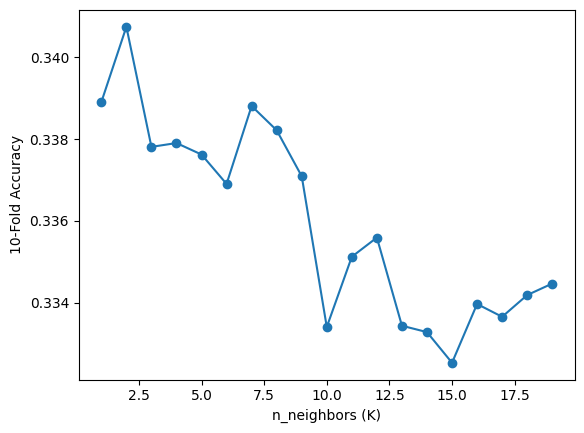

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 20))}

grid = GridSearchCV(KNeighborsClassifier(), scoring='accuracy', param_grid=param_grid, cv=10, verbose=1)
grid.fit(Xs_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(list(range(1, 20)), scores, '-o')
plt.xlabel('n_neighbors (K)')
plt.ylabel('10-Fold Accuracy')
plt.show()

In [18]:
knnModel = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors']).fit(Xs_train, y_train)

print("Train: ", knnModel.score(Xs_train, y_train))
print("Test: ", knnModel.score(Xs_test, y_test))

Train:  0.6669375
Test:  0.337625


Ahora pruebo con Regresión Logística, que es el otro modelo de clasificación 
que hemos visto en clase.

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1).fit(Xs_train, y_train)

print("Train: ", lr.score(Xs_train, y_train))
print("Test: ", lr.score(Xs_test, y_test))

Train:  0.3445625
Test:  0.33725


## 6. Evaluación

Miro la confusion matrix de los dos modelos para ver cómo están fallando.

In [20]:
from sklearn.metrics import confusion_matrix

y_pred_knn = knnModel.predict(Xs_test)
y_pred_lr = lr.predict(Xs_test)

print('--- KNN ---')
print(confusion_matrix(y_test, y_pred_knn))

print('--- Regresion Logistica ---')
print(confusion_matrix(y_test, y_pred_lr))

--- KNN ---
[[1514  901  291]
 [1494  885  276]
 [1460  877  302]]
--- Regresion Logistica ---
[[1390  658  658]
 [1324  663  668]
 [1325  669  645]]


## 7. Conclusión

El dataset tiene 40.000 filas de incidencias de ciberataques y 25 columnas. Lo que 
teníamos que predecir era la columna "Action Taken", que puede ser Blocked, Ignored 
o Logged.

Lo primero que hice fue mirar los datos: hay unas 13.300 muestras de cada clase, 
están muy equilibradas. Luego quité las columnas que no servían para nada, como las 
IPs, los timestamps o el texto del payload, porque tenían miles de valores distintos 
y un modelo no puede hacer nada con eso. Las columnas de Malware Indicators y 
Alerts/Warnings tenían la mitad de valores vacíos, así que las convertí en 0 y 1 
(tiene alerta o no tiene). El resto de columnas de texto las pasé a números con 
LabelEncoder y escalé todo con StandardScaler.

Al pintar los histogramas por clase me di cuenta de que todas las columnas se reparten 
casi exactas al 33% entre las tres clases. Es decir, da igual si miras el protocolo, 
el tipo de tráfico o el segmento de red, las tres acciones aparecen en la misma 
proporción. Eso ya me hizo sospechar que iba a ser difícil predecir algo.

Entrené dos modelos con GridSearchCV para buscar los mejores parámetros:
- KNN con el mejor K=2: accuracy de 0.337 en test
- Regresión Logística: accuracy de 0.337 en test

Los dos dan alrededor del 33%, que es lo mismo que acertar tirando un dado de 
3 caras. El KNN tiene overfitting (67% en train vs 33% en test) lo que significa 
que memoriza los datos de entrenamiento pero no sirve en datos nuevos. La regresión 
logística ni siquiera puede memorizar (34% en train).

Las confusion matrices muestran que ninguno de los dos modelos consigue distinguir 
bien las tres clases. El KNN tiende a predecir casi todo como Blocked y la regresión 
logística reparte más pero sin acertar.

Mi conclusión es que los datos que tenemos no tienen relación con la acción que se 
tomó. Probablemente la decisión de bloquear, ignorar o registrar un ataque depende 
de cosas que no están en el dataset, como las reglas internas del sistema de seguridad.